# Loading libraries

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima, ARIMA
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,r2_score, root_mean_squared_error


# Loading dataset

In [201]:
df= pd.read_csv(r"C:\Users\MINE\Desktop\Air passenger prediction\dataset\AirPassengers.csv")

In [202]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [204]:
# Setting and sorting index
df.set_index('Month', inplace=True)
df.index= pd.to_datetime(df.index)
df.sort_index(inplace=True)

In [205]:
df.index.dtype

dtype('<M8[ns]')

In [206]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [207]:
# Setting frequency and checking for null and duplicates
df=df.asfreq('MS')

In [208]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [209]:
df.shape

(144, 1)

In [210]:
df.isnull().sum()

#Passengers    0
dtype: int64

In [213]:
df.duplicated().sum()

0

In [212]:
df.drop_duplicates(keep='first', inplace=True)

# Exploratory Data Analysis

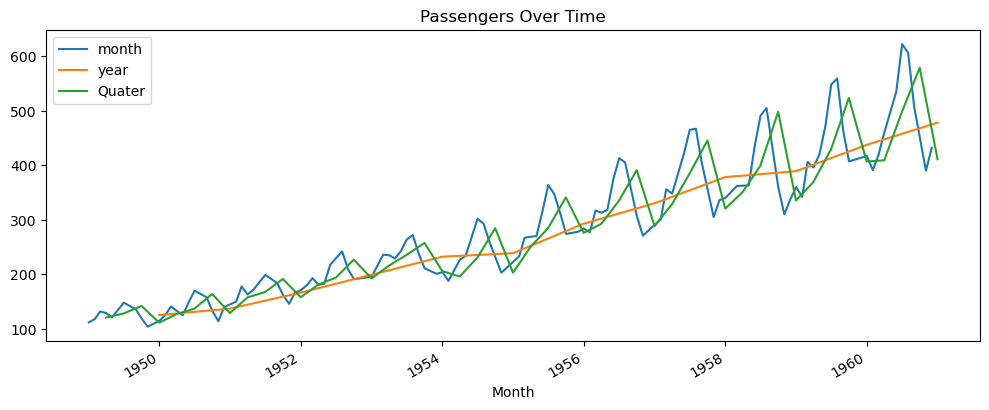

In [235]:
plt.figure(figsize=(10,4))
df['#Passengers'].plot(label='month')
df['#Passengers'].resample('YE').mean().plot(label='year')
df['#Passengers'].resample('QE').mean().plot(label='Quater')


plt.tight_layout()
plt.legend(loc='best')
plt.title('Passengers Over Time')
plt.show()

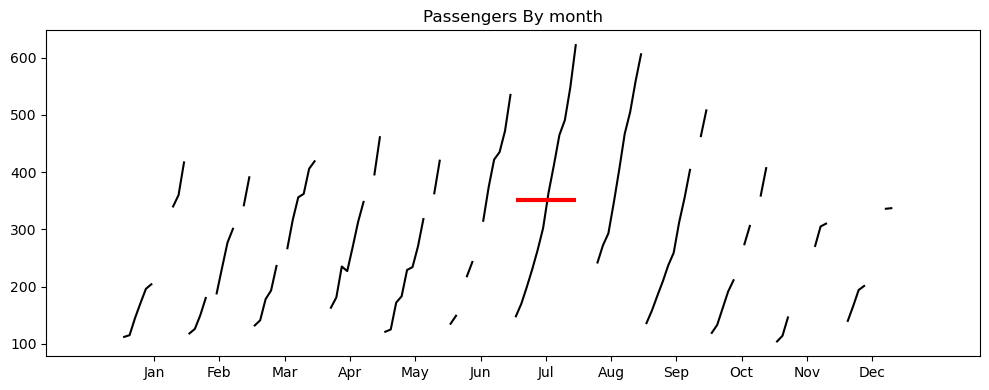

In [240]:

month_plot(df['#Passengers'].resample('ME').mean()).set_size_inches(10,4)

plt.title('Passengers By month')
plt.tight_layout()
plt.show()

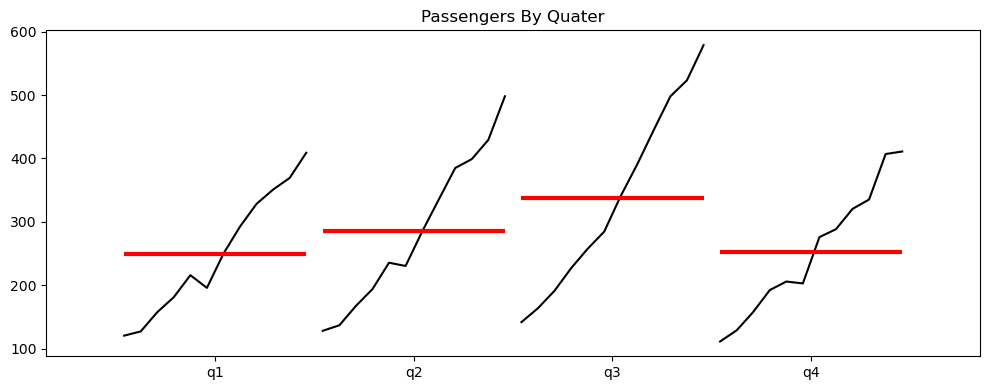

In [241]:
quarter_plot(df['#Passengers'].resample('QE').mean()).set_size_inches(10,4)

plt.title('Passengers By Quater')
plt.tight_layout()
plt.show()

In [243]:
decompose= seasonal_decompose(df['#Passengers'], model='add',period=12)

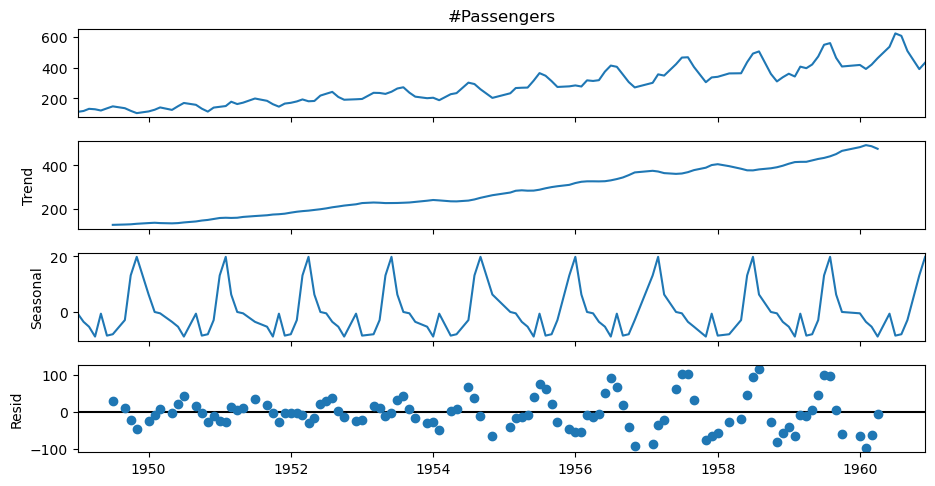

In [247]:

decompose.plot().set_size_inches(10,5)

plt.show()